# 05 — Engine 參數 Sweep：大規模速度調研

系統化掃描 TensorRT engine 的關鍵參數組合，找出最佳推論效能配置。

| 步驟 | 內容 |
|------|------|
| 1 | 路徑設定 |
| 2 | 參數網格定義 |
| 3 | 工具函式（build + parse） |
| 4 | 執行 Sweep（可中斷續跑） |
| 5 | 結果分析（Pivot table） |
| 6 | 視覺化（Heatmap / Pareto / Throughput） |

**掃描維度：** `precision` × `builderOptimizationLevel` × `workspace_mb`  
**預估時間：** 每組 ~2–5 min（含 build + benchmark），共 16 組 → 約 30–80 min  
**加速：** 使用共用 `timingCacheFile`，後續 build 顯著加快

## 1. 路徑設定

In [1]:
from pathlib import Path
import os

TRTEXEC    = Path("C:/Users/edisonhsieh/Downloads/TensorRT-10.8.0.43.Windows.win10.cuda-12.8/TensorRT-10.8.0.43/bin/trtexec.exe")
ONNX_MODEL = Path("C:/GPM_AI/H.onnx")

SWEEP_DIR     = Path("sweep")
ENGINES_SWEEP = SWEEP_DIR / "engines"
TIMING_CACHE  = SWEEP_DIR / "timing.cache"
RESULTS_CSV   = SWEEP_DIR / "sweep_results.csv"
SWEEP_DIR.mkdir(exist_ok=True)
ENGINES_SWEEP.mkdir(exist_ok=True)

WARMUP_MS  = 500    # trtexec warmup (ms)
DURATION_S = 10     # benchmark duration per config (s)

TRT_LIB = TRTEXEC.parent.parent / "lib"
if TRT_LIB.exists():
    os.environ["PATH"] = str(TRT_LIB) + os.pathsep + os.environ.get("PATH", "")
    print(f"TRT lib added to PATH : {TRT_LIB}")
else:
    print(f"WARNING: TRT lib not found at {TRT_LIB}")

assert TRTEXEC.exists(),    f"trtexec not found: {TRTEXEC}"
assert ONNX_MODEL.exists(), f"ONNX model not found: {ONNX_MODEL}"
print(f"trtexec   : {TRTEXEC}")
print(f"ONNX model: {ONNX_MODEL}")
print(f"Output dir: {SWEEP_DIR.resolve()}")
print("Settings ready.")

TRT lib added to PATH : C:\Users\edisonhsieh\Downloads\TensorRT-10.8.0.43.Windows.win10.cuda-12.8\TensorRT-10.8.0.43\lib
trtexec   : C:\Users\edisonhsieh\Downloads\TensorRT-10.8.0.43.Windows.win10.cuda-12.8\TensorRT-10.8.0.43\bin\trtexec.exe
ONNX model: C:\GPM_AI\H.onnx
Output dir: D:\tensorrt\code\notebooks\sweep
Settings ready.


## 2. 參數網格定義

| 參數 | 選項 | 說明 |
|------|------|------|
| `precision` | fp32, fp16 | 計算精度 |
| `builder_opt_level` | 0, 2, 4, 5 | 0=快速 build，5=最激進優化（build 最慢） |
| `workspace_mb` | 256, 1024 | GPU workspace 大小（MB）|

如需加入 INT8 / 動態 batch，見 cell 末尾的擴充說明。

In [2]:
import itertools

PARAM_GRID = {
    "precision":         ["fp32", "fp16"],
    "builder_opt_level": [0, 2, 4, 5],
    "workspace_mb":      [256, 1024],
    # "sparsity":        [False, True],  # 啟用 structured sparsity（需模型本身有 sparse 權重）
}

configs = [
    dict(zip(PARAM_GRID.keys(), values))
    for values in itertools.product(*PARAM_GRID.values())
]

print(f"Total configurations : {len(configs)}")
print(f"Estimated time       : {len(configs) * 2}–{len(configs) * 5} min\n")
print(f"{'#':>3}  {'precision':>10}  {'opt_level':>9}  {'workspace_mb':>12}")
print("-" * 42)
for i, c in enumerate(configs):
    print(f"{i:3d}  {c['precision']:>10}  {c['builder_opt_level']:>9}  {c['workspace_mb']:>12}")

Total configurations : 16
Estimated time       : 32–80 min

  #   precision  opt_level  workspace_mb
------------------------------------------
  0        fp32          0           256
  1        fp32          0          1024
  2        fp32          2           256
  3        fp32          2          1024
  4        fp32          4           256
  5        fp32          4          1024
  6        fp32          5           256
  7        fp32          5          1024
  8        fp16          0           256
  9        fp16          0          1024
 10        fp16          2           256
 11        fp16          2          1024
 12        fp16          4           256
 13        fp16          4          1024
 14        fp16          5           256
 15        fp16          5          1024


## 3. 工具函式

In [3]:
import subprocess, time, re


def parse_trtexec(stdout: str) -> dict:
    patterns = {
        "mean_ms":        r"mean\s*=\s*([\d.]+)\s*ms",
        "median_ms":      r"median\s*=\s*([\d.]+)\s*ms",
        "p95_ms":         r"95th percentile.*?=\s*([\d.]+)\s*ms",
        "p99_ms":         r"99th percentile.*?=\s*([\d.]+)\s*ms",
        "throughput_qps": r"Throughput:\s*([\d.]+)\s*qps",
        "gpu_compute_ms": r"GPU Compute Time.*?mean\s*=\s*([\d.]+)\s*ms",
    }
    return {
        k: float(m.group(1))
        for k, pat in patterns.items()
        if (m := re.search(pat, stdout, re.IGNORECASE))
    }


def build_and_benchmark(cfg: dict, engine_path: Path) -> dict:
    cmd = [
        str(TRTEXEC),
        f"--onnx={ONNX_MODEL}",
        f"--saveEngine={engine_path}",
        f"--warmUp={WARMUP_MS}",
        f"--duration={DURATION_S}",
        f"--builderOptimizationLevel={cfg['builder_opt_level']}",
        f"--memPoolSize=workspace:{cfg['workspace_mb']}m",
        f"--timingCacheFile={TIMING_CACHE}",
    ]
    if cfg["precision"] == "fp16":
        cmd.append("--fp16")

    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    build_time_s = round(time.time() - t0, 1)

    result = {**cfg, "build_time_s": build_time_s, "success": proc.returncode == 0}
    if proc.returncode == 0:
        result.update(parse_trtexec(proc.stdout))
    else:
        result["error"] = proc.stderr[-500:].strip()
    return result


print("Helper functions loaded.")

Helper functions loaded.


## 4. 執行 Sweep

- 結果每組完成後即寫入 `sweep/sweep_results.csv`（可中斷後續跑）
- 已完成的 config 會自動跳過（依 `precision + opt_level + workspace_mb` 判斷）
- Engine 檔案儲存於 `sweep/engines/`

In [4]:
import pandas as pd
from tqdm.auto import tqdm


def config_key(cfg: dict) -> str:
    return f"{cfg['precision']}__opt{cfg['builder_opt_level']}__ws{cfg['workspace_mb']}"


if RESULTS_CSV.exists():
    df_prev = pd.read_csv(RESULTS_CSV)
    done_keys = set(
        df_prev.apply(
            lambda r: f"{r.precision}__opt{int(r.builder_opt_level)}__ws{int(r.workspace_mb)}",
            axis=1,
        )
    )
    results = df_prev.to_dict("records")
    print(f"Resuming: {len(done_keys)} done, {len(configs) - len(done_keys)} remaining")
else:
    done_keys = set()
    results = []
    print(f"Starting fresh sweep ({len(configs)} configs)")

pbar = tqdm(configs, desc="Sweep", unit="cfg")
for i, cfg in enumerate(pbar):
    key = config_key(cfg)
    if key in done_keys:
        pbar.set_postfix_str(f"skip {key}")
        continue

    engine_name = f"H_{cfg['precision']}_opt{cfg['builder_opt_level']}_ws{cfg['workspace_mb']}mb.engine"
    engine_path = ENGINES_SWEEP / engine_name

    pbar.set_postfix_str(f"{cfg['precision']} opt={cfg['builder_opt_level']} ws={cfg['workspace_mb']}")
    res = build_and_benchmark(cfg, engine_path)
    results.append(res)

    pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)

    if res["success"]:
        print(
            f"  [{i+1:02d}/{len(configs)}] {cfg['precision']:>4} opt={cfg['builder_opt_level']} "
            f"ws={cfg['workspace_mb']:>4}MB  "
            f"mean={res.get('mean_ms', float('nan')):.3f}ms  "
            f"QPS={res.get('throughput_qps', float('nan')):.1f}  "
            f"build={res['build_time_s']}s"
        )
    else:
        print(f"  [{i+1:02d}/{len(configs)}] FAILED: {cfg}")
        print(f"    {res.get('error', '')[:200]}")

df = pd.DataFrame(results)
n_ok = df["success"].sum() if "success" in df.columns else 0
print(f"\nSweep complete — {n_ok}/{len(configs)} succeeded")
print(f"Results saved → {RESULTS_CSV}")

d:\tensorrt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting fresh sweep (16 configs)


Sweep:   6%|▋         | 1/16 [00:26<06:38, 26.59s/cfg, fp32 opt=0 ws=1024]

  [01/16] fp32 opt=0 ws= 256MB  mean=3.849ms  QPS=248.9  build=26.6s


Sweep:  12%|█▎        | 2/16 [00:45<05:05, 21.86s/cfg, fp32 opt=2 ws=256] 

...

  [14/16] fp16 opt=4 ws=1024MB  mean=1.401ms  QPS=651.4  build=28.8s


Sweep:  94%|█████████▍| 15/16 [07:08<00:34, 34.13s/cfg, fp16 opt=5 ws=1024]

  [15/16] fp16 opt=5 ws= 256MB  mean=1.415ms  QPS=645.8  build=38.3s


Sweep: 100%|██████████| 16/16 [07:43<00:00, 28.98s/cfg, fp16 opt=5 ws=1024]

  [16/16] fp16 opt=5 ws=1024MB  mean=1.429ms  QPS=637.0  build=35.7s

Sweep complete — 16/16 succeeded
Results saved → sweep\sweep_results.csv


## 5. 結果分析

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv(RESULTS_CSV)
df_ok = df[df["success"] == True].copy()
df_ok["builder_opt_level"] = df_ok["builder_opt_level"].astype(int)
df_ok["workspace_mb"]      = df_ok["workspace_mb"].astype(int)

print(f"Successful configs: {len(df_ok)} / {len(df)}\n")

# Pivot: opt_level × precision, mean latency, grouped by workspace
for ws, grp in df_ok.groupby("workspace_mb"):
    pivot = grp.pivot_table(
        index="builder_opt_level", columns="precision", values="mean_ms"
    ).rename_axis(None, axis=1)
    print(f"=== workspace = {ws} MB — Mean Latency (ms, lower is better) ===")
    print(pivot.round(3).to_string())
    print()

# Full sorted table
cols = ["precision", "builder_opt_level", "workspace_mb",
        "mean_ms", "gpu_compute_ms", "throughput_qps", "build_time_s"]
avail_cols = [c for c in cols if c in df_ok.columns]
print("=== All Results (sorted by mean_ms) ===")
print(
    df_ok[avail_cols]
    .sort_values("mean_ms")
    .to_string(index=False, float_format="{:.3f}".format)
)

# Best config
best = df_ok.loc[df_ok["mean_ms"].idxmin()]
print(f"\n>>> Best config (lowest latency):")
print(f"    precision={best['precision']}  opt_level={int(best['builder_opt_level'])}  "
      f"workspace={int(best['workspace_mb'])}MB")
print(f"    mean_ms={best['mean_ms']:.3f}  QPS={best.get('throughput_qps', float('nan')):.1f}  "
      f"build_time={best['build_time_s']}s")

Successful configs: 16 / 16

=== workspace = 256 MB — Mean Latency (ms, lower is better) ===
                    fp16   fp32
builder_opt_level              
0                  2.041  3.849
2                  1.471  3.586
4                  1.458  3.505
5                  1.415  3.418

=== workspace = 1024 MB — Mean Latency (ms, lower is better) ===
                    fp16   fp32
builder_opt_level              
0                  2.066  4.111
2                  1.519  3.598
4                  1.401  3.476
5                  1.429  3.437

=== All Results (sorted by mean_ms) ===
precision  builder_opt_level  workspace_mb  mean_ms  gpu_compute_ms  throughput_qps  build_time_s
     fp16                  4          1024    1.401           1.289         651.402        28.800
     fp16                  5           256    1.415           1.301         645.788        38.300
     fp16                  5          1024    1.429           1.313         636.954        35.700
     fp16               

## 6. 視覺化

四張圖：
1. **Heatmap × 2**：opt_level × precision 的 mean latency（分 workspace）
2. **Pareto scatter**：build cost vs inference speed
3. **Throughput bar**：Top configs by QPS

seaborn not installed — using matplotlib fallback for heatmaps


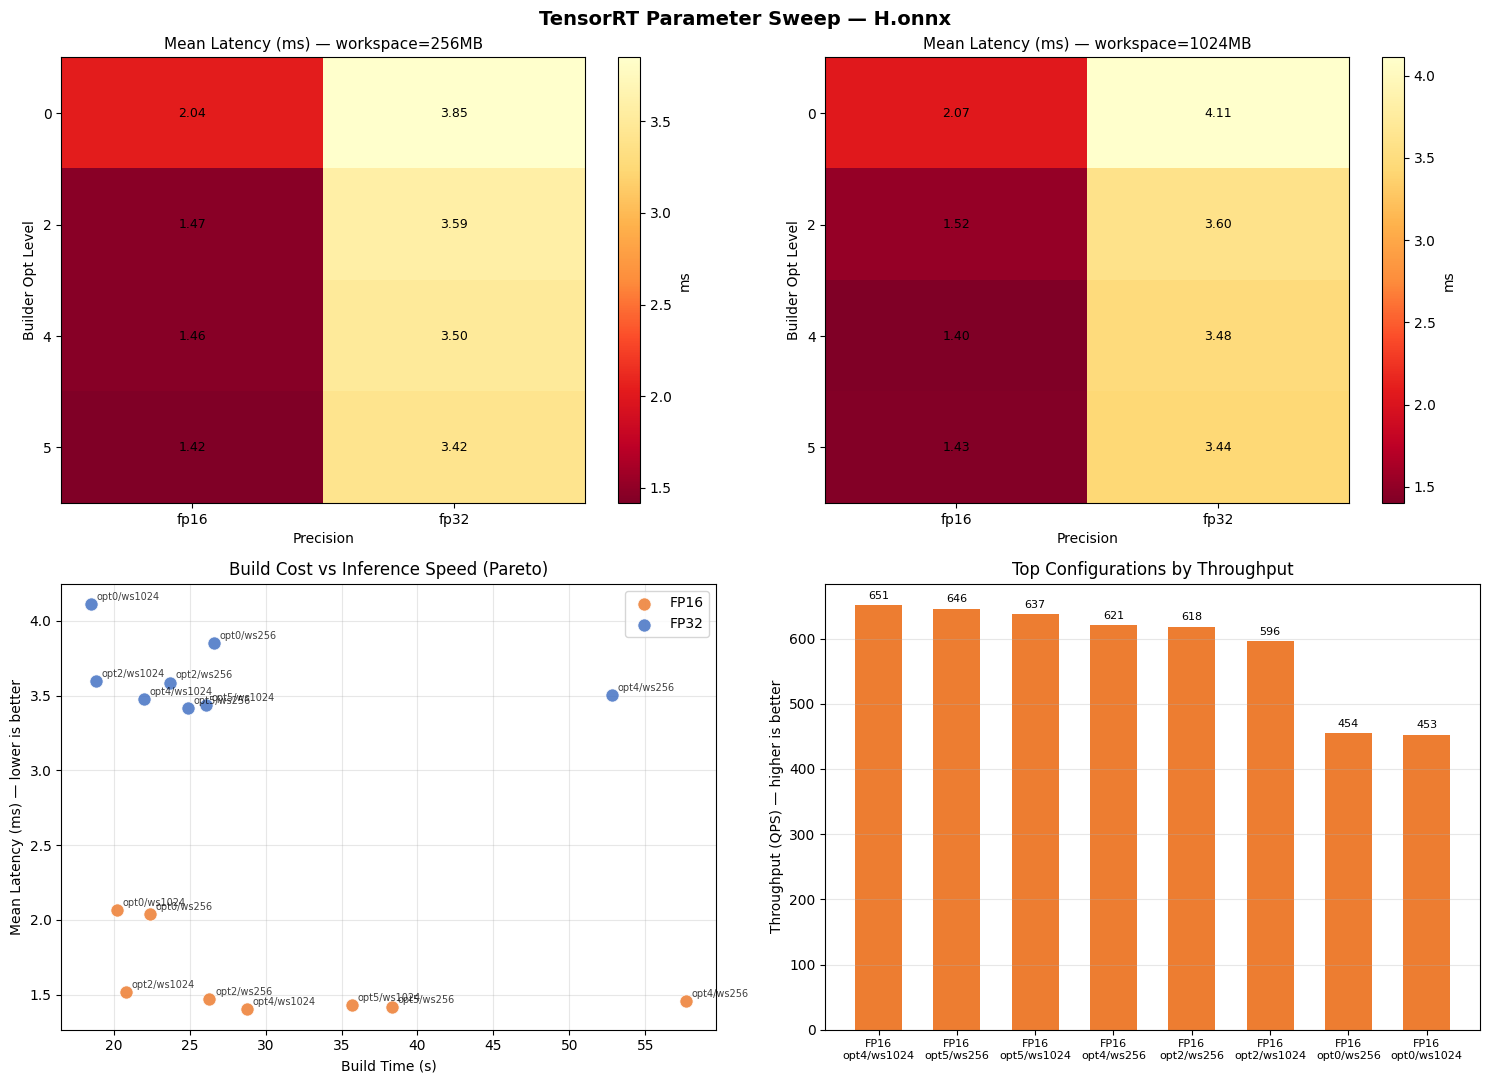

Saved → sweep\sweep_results.png


In [6]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False
    print("seaborn not installed — using matplotlib fallback for heatmaps")

PREC_COLORS = {"fp32": "#4472C4", "fp16": "#ED7D31"}
ws_groups = sorted(df_ok["workspace_mb"].unique())

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ── Heatmaps (one per workspace) ─────────────────────────────────────────────
for ax, ws in zip(axes[0], ws_groups[:2]):
    sub = df_ok[df_ok["workspace_mb"] == ws]
    pivot = sub.pivot_table(
        index="builder_opt_level", columns="precision", values="mean_ms"
    )
    if HAS_SNS:
        sns.heatmap(
            pivot, annot=True, fmt=".2f", cmap="YlOrRd_r",
            ax=ax, linewidths=0.5, cbar_kws={"label": "ms"}
        )
    else:
        im = ax.imshow(pivot.values, cmap="YlOrRd_r", aspect="auto")
        plt.colorbar(im, ax=ax, label="ms")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        for r in range(pivot.shape[0]):
            for c in range(pivot.shape[1]):
                v = pivot.values[r, c]
                if not np.isnan(v):
                    ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(f"Mean Latency (ms) — workspace={ws}MB", fontsize=11)
    ax.set_xlabel("Precision")
    ax.set_ylabel("Builder Opt Level")

# ── Pareto: build time vs mean latency ───────────────────────────────────────
ax = axes[1, 0]
for prec, grp in df_ok.groupby("precision"):
    ax.scatter(
        grp["build_time_s"], grp["mean_ms"],
        c=PREC_COLORS[prec], label=prec.upper(),
        s=90, alpha=0.85, edgecolors="white", linewidths=0.6, zorder=3
    )
    for _, row in grp.iterrows():
        ax.annotate(
            f"opt{int(row.builder_opt_level)}/ws{int(row.workspace_mb)}",
            (row.build_time_s, row.mean_ms),
            fontsize=7, xytext=(4, 3), textcoords="offset points", alpha=0.75
        )
ax.set_xlabel("Build Time (s)")
ax.set_ylabel("Mean Latency (ms) — lower is better")
ax.set_title("Build Cost vs Inference Speed (Pareto)")
ax.legend()
ax.grid(alpha=0.3)

# ── Throughput bar — top 8 configs ───────────────────────────────────────────
ax = axes[1, 1]
top = df_ok.sort_values("throughput_qps", ascending=False).head(8)
bar_labels = top.apply(
    lambda r: f"{r.precision.upper()}\nopt{int(r.builder_opt_level)}/ws{int(r.workspace_mb)}",
    axis=1,
)
bar_colors = [PREC_COLORS[p] for p in top["precision"]]
bars = ax.bar(range(len(top)), top["throughput_qps"], color=bar_colors, width=0.6)
ax.set_xticks(range(len(top)))
ax.set_xticklabels(bar_labels, fontsize=8)
ax.set_ylabel("Throughput (QPS) — higher is better")
ax.set_title("Top Configurations by Throughput")
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, top["throughput_qps"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(top["throughput_qps"]) * 0.01,
        f"{val:.0f}", ha="center", va="bottom", fontsize=8
    )

plt.suptitle("TensorRT Parameter Sweep — H.onnx", fontsize=14, fontweight="bold")
plt.tight_layout()

out_png = SWEEP_DIR / "sweep_results.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_png}")